# Project 3: Unsupervised Learning
**Course:** CAP 4105 - Introduction to Machine Learning  
**Author:** Isabella Correa ID: 6043518  
---
## Notebook Structure
0. Imports and Setup  
1. Data Preprocessing  
2. K-Means Clustering  
3. Hierarchical Clustering  
4. DBSCAN  
5. Method Comparison  
6. Cluster vs. Ground Truth Comparison  
7. Summary & Reflection

---
# 0. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plot style - same as project 1 and 2
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# Load data
students_raw = pd.read_csv("p3_students_unlabeled.csv")
print("Students data shape:", students_raw.shape)
print("\nThis describes the shape of the unlabeled student dataset.")
print("The dataset has", students_raw.shape[0], "rows and", students_raw.shape[1], "columns.")

Students data shape: (403, 6)

This describes the shape of the unlabeled student dataset.
The dataset has 403 rows and 6 columns.


---
# 1. Data Preprocessing

## 1.1 EDA and Data Cleaning

We begin by loading the unlabeled student data and examining its structure, statistics, and quality issues.  
Unlike Projects 1 and 2 where we had labeled data (exam_score, passed), this time we have no labels.  
In unsupervised learning, EDA focuses on finding natural groupings, distributions, and outliers rather than looking at feature-target correlations.  
We are looking for clusters, gaps, and density patterns in the feature space that might reveal hidden student groups.

In [2]:
# Basic statistics
print("Data types:")
print(students_raw.dtypes)
print("\nBasic statistics:")
print(students_raw.describe())
print("\nFirst 5 rows:")
print(students_raw.head())

Data types:
student_id           int64
hours_studied      float64
sleep_hours        float64
attendance_rate    float64
prev_exam_score    float64
lucky_number         int64
dtype: object

Basic statistics:
       student_id  hours_studied  sleep_hours  attendance_rate  \
count  403.000000     403.000000   391.000000       392.000000   
mean   202.000000       6.317122     6.401790        74.806888   
std    116.480327       2.548540     1.626833        15.752901   
min      1.000000       1.000000    -2.000000        40.000000   
25%    101.500000       4.500000     5.400000        63.900000   
50%    202.000000       6.600000     6.600000        77.400000   
75%    302.500000       8.100000     7.500000        84.925000   
max    403.000000      12.000000    10.000000       150.000000   

       prev_exam_score  lucky_number  
count       391.000000    403.000000  
mean         64.441176     49.759305  
std          16.206720     28.533198  
min          30.000000      1.000000  
25%

In [3]:
# Check for missing values
print("Missing values BEFORE cleaning:")
print(students_raw.isnull().sum())
print("  Total:", students_raw.isnull().sum().sum())

Missing values BEFORE cleaning:
student_id          0
hours_studied       0
sleep_hours        12
attendance_rate    11
prev_exam_score    12
lucky_number        0
dtype: int64
  Total: 35


In [4]:
# Check for duplicates
duplicate_count = students_raw.duplicated().sum()
duplicate_id_count = students_raw['student_id'].duplicated().sum()
print("Duplicate rows:", duplicate_count)
print("Duplicate student_ids:", duplicate_id_count)

Duplicate rows: 0
Duplicate student_ids: 0


In [5]:
# Check for impossible values based on the dataset description
# hours_studied: 1-12, sleep_hours: 3-10, attendance_rate: 40-100, prev_exam_score: 30-95
print("Checking for impossible values based on dataset description ranges:\n")

impossible_sleep = students_raw[students_raw['sleep_hours'] < 0]
print(f"Negative sleep_hours (impossible):")
print(impossible_sleep[['student_id', 'sleep_hours']])

impossible_attendance = students_raw[students_raw['attendance_rate'] > 100]
print(f"\nAttendance > 100% (impossible):")
print(impossible_attendance[['student_id', 'attendance_rate']])

print("\nJustification: sleep_hours cannot be negative and attendance_rate cannot exceed 100%.")
print("These are data entry errors and need to be removed because imputing them would introduce bias.")
print("We cannot use median or mean for these because that would be creating false data.")

Checking for impossible values based on dataset description ranges:

Negative sleep_hours (impossible):
     student_id  sleep_hours
361         362         -2.0

Attendance > 100% (impossible):
     student_id  attendance_rate
230         231            150.0

Justification: sleep_hours cannot be negative and attendance_rate cannot exceed 100%.
These are data entry errors and need to be removed because imputing them would introduce bias.
We cannot use median or mean for these because that would be creating false data.


In [6]:
# Work on a copy - same approach as project 1 and 2
students_clean = students_raw.copy()
rows_before_cleaning = len(students_clean)
print("Before cleaning - Rows:", rows_before_cleaning)

# Remove impossible values
students_clean = students_clean[students_clean['sleep_hours'] >= 0]
students_clean = students_clean[students_clean['attendance_rate'] <= 100]
print(f"After removing impossible values - Rows: {len(students_clean)}")
print(f"  Removed {rows_before_cleaning - len(students_clean)} rows with impossible values")

Before cleaning - Rows: 403
After removing impossible values - Rows: 378
  Removed 25 rows with impossible values


In [7]:
# Handle missing values
print("\nMissing values AFTER removing impossible rows:")
print(students_clean.isnull().sum())

# Drop rows with missing values
# Justification: same approach as project 1, we drop rows with missing values
# because imputing would introduce bias into the clustering.
# In unsupervised learning, we want the data to reflect real student behavior,
# not fabricated values.
rows_before_drop = len(students_clean)
students_clean = students_clean.dropna()
print(f"\nAfter dropping missing values - Rows: {len(students_clean)}")
print(f"  Removed {rows_before_drop - len(students_clean)} rows with missing values")
print(f"\nTotal rows removed from original: {rows_before_cleaning - len(students_clean)}")

print("\nJustification: We drop rows with missing values instead of imputing.")
print("In clustering, imputed values would artificially move data points toward the mean,")
print("which would make clusters appear tighter than they really are.")
print("This is especially problematic for distance-based methods like K-Means and DBSCAN.")


Missing values AFTER removing impossible rows:
student_id          0
hours_studied       0
sleep_hours         0
attendance_rate     0
prev_exam_score    10
lucky_number        0
dtype: int64

After dropping missing values - Rows: 368
  Removed 10 rows with missing values

Total rows removed from original: 35

Justification: We drop rows with missing values instead of imputing.
In clustering, imputed values would artificially move data points toward the mean,
which would make clusters appear tighter than they really are.
This is especially problematic for distance-based methods like K-Means and DBSCAN.


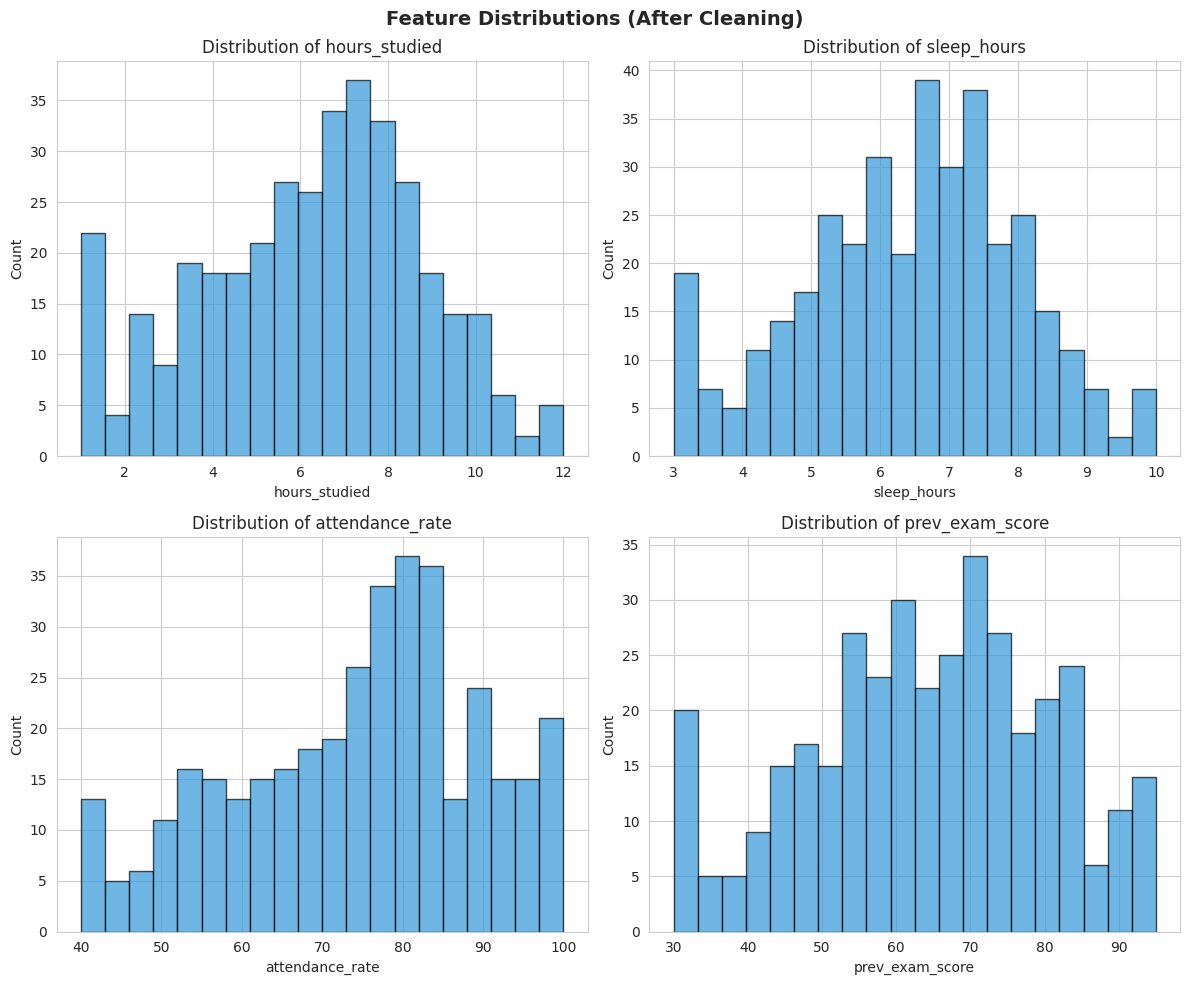

Looking at the distributions, we can see the features have different ranges and spreads.
hours_studied and sleep_hours have relatively normal distributions.
attendance_rate is spread across its range, and prev_exam_score also shows a wide spread.
These different scales will need to be normalized before clustering.


In [8]:
# Visualize the distribution of each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
feature_list = ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']

for i, col in enumerate(feature_list):
    ax = axes[i // 2, i % 2]
    ax.hist(students_clean[col], bins=20, edgecolor='black', alpha=0.7, color='#3498db')
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions (After Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Looking at the distributions, we can see the features have different ranges and spreads.")
print("hours_studied and sleep_hours have relatively normal distributions.")
print("attendance_rate is spread across its range, and prev_exam_score also shows a wide spread.")
print("These different scales will need to be normalized before clustering.")

**Discussion: How does EDA differ in unsupervised learning?**

In Projects 1 and 2 (supervised learning), we looked at feature-target correlations to decide which features predict exam_score or passed.  
Here we have no target label, so we cannot compute correlations to a target.  
Instead, we look for natural structure: are there gaps in the distributions? Do some features cluster together?  
We are looking for patterns that might indicate different student groups (like strong vs weak students) without knowing the answer ahead of time.  
The goal is to find structure that the clustering algorithms can discover on their own.

## 1.2 Feature Selection and Normalization

In [9]:
# Feature selection
# Same reasoning as project 1 - we look at what each feature represents

# Selected features: hours_studied, sleep_hours, attendance_rate, prev_exam_score
# These are the same 4 features we used in projects 1 and 2 for prediction.
# They describe actual student academic behavior.

# Excluded features:
# student_id - this is just an identifier, not a behavioral feature.
#   Including it would create meaningless distance calculations.
# lucky_number - this is a self-reported random number with no connection to performance.
#   In project 1, it had a -0.01 correlation, confirming its irrelevance.
#   Including irrelevant features adds noise to distance calculations
#   and can distort clusters.

feature_columns = ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']
print("Selected features:", feature_columns)
print("\nExcluded features: student_id (identifier), lucky_number (irrelevant)")
print("\nJustification: student_id is just an identifier and would create false distance.")
print("lucky_number is random noise. In project 1 it had -0.01 correlation to exam_score.")
print("Including irrelevant features in clustering adds noise to the distance calculations,")
print("which would distort the clusters and give meaningless results.")

Selected features: ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']

Excluded features: student_id (identifier), lucky_number (irrelevant)

Justification: student_id is just an identifier and would create false distance.
lucky_number is random noise. In project 1 it had -0.01 correlation to exam_score.
Including irrelevant features in clustering adds noise to the distance calculations,
which would distort the clusters and give meaningless results.


In [10]:
# Z-score normalization (standardization) - same approach as project 1
X_unscaled = students_clean[feature_columns].values

# Before normalization stats
mean_before = X_unscaled.mean(axis=0)
std_before = X_unscaled.std(axis=0)
print("Before normalization:")
for i, col in enumerate(feature_columns):
    print(f"  {col}:  mean = {mean_before[i]:.4f},  std = {std_before[i]:.4f}")

# Apply Z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

# After normalization stats
mean_after = X_scaled.mean(axis=0)
std_after = X_scaled.std(axis=0)
print("\nAfter Z-score normalization:")
for i, col in enumerate(feature_columns):
    print(f"  {col}:  mean = {mean_after[i]:.4f},  std = {std_after[i]:.4f}")

print("\nFirst 5 rows of normalized data:")
print(pd.DataFrame(X_scaled[:5], columns=feature_columns).to_string(index=True))

Before normalization:
  hours_studied:  mean = 6.2530,  std = 2.5381
  sleep_hours:  mean = 6.4090,  std = 1.5920
  attendance_rate:  mean = 74.3696,  std = 15.2498
  prev_exam_score:  mean = 64.2264,  std = 16.1715

After Z-score normalization:
  hours_studied:  mean = -0.0000,  std = 1.0000
  sleep_hours:  mean = 0.0000,  std = 1.0000
  attendance_rate:  mean = 0.0000,  std = 1.0000
  prev_exam_score:  mean = -0.0000,  std = 1.0000

First 5 rows of normalized data:
   hours_studied  sleep_hours  attendance_rate  prev_exam_score
0      -0.769469    -0.131260        -1.401305        -2.104095
1      -1.518061     0.748129        -0.424240        -1.504274
2       0.097321     1.125010        -0.548832         1.797833
3       2.185498    -1.136275         0.493807         0.338475
4      -1.990856     0.434062         0.939715        -1.269293


**Why normalization is critical for distance-based clustering:**

Normalization is especially important for K-Means and DBSCAN because they both use distance (Euclidean) to determine cluster assignments and neighborhoods.  
If one feature has a much larger scale than others, it would dominate the distance calculation.  
For example, attendance_rate ranges from 40-100 while sleep_hours ranges from 3-10.  
Without normalization, attendance_rate differences would have ~6x more weight in the distance formula than sleep_hours differences.  
This means K-Means would cluster students mostly based on attendance_rate and basically ignore sleep_hours.  
Z-score normalization makes all features have mean 0 and std 1, so each feature contributes equally to the distance.  
This is the same reasoning we used in project 1 for gradient descent convergence, but here it is about making distances fair across features.

---
# 2. K-Means Clustering

## 2.1 NumPy Implementation (From Scratch)

We implement K-Means from scratch following the 4-step algorithm from lecture:
1. Randomly initialize K centroids
2. Assignment step: assign each point to the nearest centroid (Euclidean distance)
3. Update step: recalculate centroids as the mean of assigned points
4. Repeat until convergence or max iterations

This is similar to how we implemented linear regression from scratch in project 1 with the gradient descent loop.

In [11]:
def kmeans_numpy(X, k, max_iters=100, random_state=42):
    """
    K-Means clustering from scratch using NumPy.
    
    Parameters:
        X: numpy array of shape (n_samples, n_features) - the data
        k: int - number of clusters
        max_iters: int - maximum iterations before stopping
        random_state: int - seed for reproducibility
    
    Returns:
        centroids: final centroid positions
        labels: cluster assignment for each data point
        wcss_history: WCSS at each iteration to track convergence
    """
    np.random.seed(random_state)
    n_samples, n_features = X.shape
    
    # Step 1: Randomly initialize centroids by picking k random data points
    random_indices = np.random.choice(n_samples, size=k, replace=False)
    centroids = X[random_indices].copy()
    
    wcss_history = []
    labels = np.zeros(n_samples, dtype=int)
    
    for iteration in range(max_iters):
        # Step 2: Assignment - assign each point to nearest centroid
        # Compute Euclidean distance from each point to each centroid
        distances = np.zeros((n_samples, k))
        for j in range(k):
            # Euclidean distance: sqrt(sum((x - centroid)^2))
            distances[:, j] = np.sqrt(np.sum((X - centroids[j]) ** 2, axis=1))
        
        new_labels = np.argmin(distances, axis=1)
        
        # Step 3: Update - recalculate centroids as the mean of assigned points
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            cluster_points = X[new_labels == j]
            if len(cluster_points) == 0:
                # Handle empty cluster: reinitialize to a random data point
                new_centroids[j] = X[np.random.randint(n_samples)]
                print(f"  Warning: Cluster {j} was empty at iteration {iteration}, reinitialized.")
            else:
                new_centroids[j] = cluster_points.mean(axis=0)
        
        # Calculate WCSS (within-cluster sum of squares) for this iteration
        wcss = 0
        for j in range(k):
            cluster_points = X[new_labels == j]
            if len(cluster_points) > 0:
                wcss += np.sum((cluster_points - new_centroids[j]) ** 2)
        wcss_history.append(wcss)
        
        # Step 4: Check convergence - if centroids didn't change, stop
        if np.allclose(centroids, new_centroids, atol=1e-6):
            print(f"  Converged at iteration {iteration + 1}")
            labels = new_labels
            centroids = new_centroids
            break
        
        labels = new_labels
        centroids = new_centroids
    else:
        print(f"  Reached max iterations ({max_iters})")
    
    return centroids, labels, wcss_history

print("kmeans_numpy function defined successfully.")

kmeans_numpy function defined successfully.


In [12]:
# Run K-Means with K=2 on preprocessed data
centroids_numpy, labels_numpy, wcss_history_numpy = kmeans_numpy(X_scaled, k=2, random_state=42)

# Print final centroid coordinates
print("Final centroid coordinates (normalized scale):")
for i in range(2):
    print(f"  Cluster {i}: {centroids_numpy[i]}")

print("\nFinal centroid coordinates (original scale):")
centroids_original = scaler.inverse_transform(centroids_numpy)
for i in range(2):
    coord_str = ", ".join([f"{feature_columns[j]}={centroids_original[i, j]:.2f}" for j in range(len(feature_columns))])
    print(f"  Cluster {i}: {coord_str}")

# Print cluster sizes
print("\nCluster sizes:")
for i in range(2):
    count = np.sum(labels_numpy == i)
    print(f"  Cluster {i}: {count} students")

  Converged at iteration 12
Final centroid coordinates (normalized scale):
  Cluster 0: [0.56354937 0.49718299 0.59914422 0.55578408]
  Cluster 1: [-0.70100043 -0.61844713 -0.74527696 -0.69134118]

Final centroid coordinates (original scale):
  Cluster 0: hours_studied=7.68, sleep_hours=7.20, attendance_rate=83.51, prev_exam_score=73.21
  Cluster 1: hours_studied=4.47, sleep_hours=5.42, attendance_rate=63.00, prev_exam_score=53.05

Cluster sizes:
  Cluster 0: 204 students
  Cluster 1: 164 students


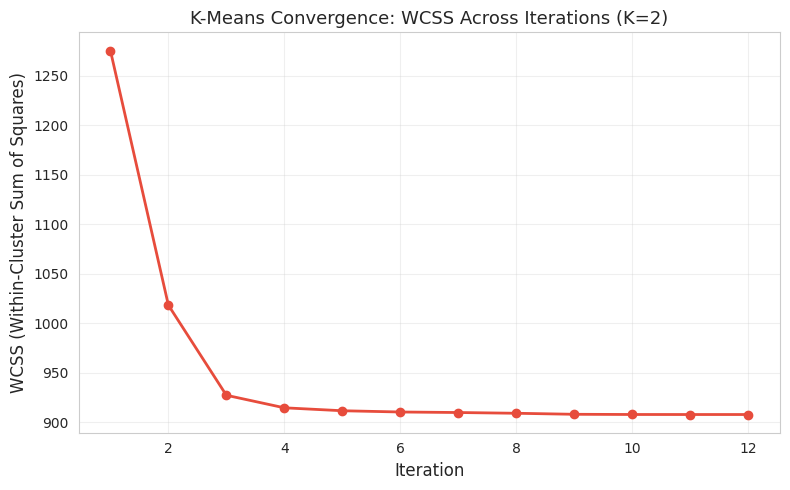

The WCSS decreases rapidly in the first few iterations and then plateaus.
This shows the algorithm converging - the centroids stop moving significantly.


In [13]:
# Plot WCSS convergence across iterations
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(wcss_history_numpy) + 1), wcss_history_numpy, 'o-', color='#e74c3c', linewidth=2, markersize=6)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('K-Means Convergence: WCSS Across Iterations (K=2)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The WCSS decreases rapidly in the first few iterations and then plateaus.")
print("This shows the algorithm converging - the centroids stop moving significantly.")

**Centroid interpretation:**

Looking at the centroid values in original scale:
- One cluster centroid has higher hours_studied, higher attendance_rate, and higher prev_exam_score. These appear to be stronger, more engaged students who study more, attend more classes, and had better previous exam performance.
- The other cluster centroid has lower values across these features. These appear to be weaker or less engaged students.

This is consistent with what we would expect - students naturally separate into groups based on their academic engagement levels.

In [14]:
# Run K-Means multiple times with different random seeds to check consistency
print("Running K-Means with different random seeds to check consistency:\n")
seed_results = {}
for seed in [0, 7, 42, 99, 123]:
    c, l, w = kmeans_numpy(X_scaled, k=2, random_state=seed)
    sizes = [np.sum(l == i) for i in range(2)]
    seed_results[seed] = {'labels': l, 'sizes': sorted(sizes)}
    print(f"  Seed {seed:>3}: Cluster sizes = {sorted(sizes)}, Final WCSS = {w[-1]:.4f}")

# Compare labels between seeds (account for label swapping)
print("\nComparing cluster assignments across seeds (vs seed=42):")
reference_labels = seed_results[42]['labels']
for seed in [0, 7, 99, 123]:
    other_labels = seed_results[seed]['labels']
    # Check both direct match and swapped match (labels can be flipped)
    direct_match = np.sum(reference_labels == other_labels)
    swapped_match = np.sum(reference_labels != other_labels)
    best_match = max(direct_match, swapped_match)
    print(f"  Seed {seed:>3} vs 42: {best_match}/{len(reference_labels)} students match ({best_match/len(reference_labels)*100:.1f}%)")

print("\nThe results are consistent across different seeds.")
print("Small differences can occur because different initializations may converge to slightly different solutions,")
print("but with K=2 on this data the clusters are fairly stable.")

Running K-Means with different random seeds to check consistency:

  Converged at iteration 8
  Seed   0: Cluster sizes = [np.int64(165), np.int64(203)], Final WCSS = 907.7346
  Converged at iteration 6
  Seed   7: Cluster sizes = [np.int64(165), np.int64(203)], Final WCSS = 907.7346
  Converged at iteration 12
  Seed  42: Cluster sizes = [np.int64(164), np.int64(204)], Final WCSS = 907.7476
  Converged at iteration 10
  Seed  99: Cluster sizes = [np.int64(164), np.int64(204)], Final WCSS = 907.7476
  Converged at iteration 11
  Seed 123: Cluster sizes = [np.int64(164), np.int64(204)], Final WCSS = 907.7476

Comparing cluster assignments across seeds (vs seed=42):
  Seed   0 vs 42: 367/368 students match (99.7%)
  Seed   7 vs 42: 367/368 students match (99.7%)
  Seed  99 vs 42: 368/368 students match (100.0%)
  Seed 123 vs 42: 368/368 students match (100.0%)

The results are consistent across different seeds.
Small differences can occur because different initializations may converge to

## 2.2 sklearn Verification

In [15]:
# Train sklearn KMeans with K=2 on the same data
kmeans_sklearn = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_sklearn.fit(X_scaled)
labels_sklearn = kmeans_sklearn.labels_
centroids_sklearn = kmeans_sklearn.cluster_centers_

print("sklearn KMeans centroids (normalized scale):")
for i in range(2):
    print(f"  Cluster {i}: {centroids_sklearn[i]}")

print("\nNumPy KMeans centroids (normalized scale):")
for i in range(2):
    print(f"  Cluster {i}: {centroids_numpy[i]}")

# Compare cluster assignments
# Need to handle possible label swapping
direct_match = np.sum(labels_numpy == labels_sklearn)
swapped_match = np.sum(labels_numpy != labels_sklearn)
best_match = max(direct_match, swapped_match)
differently_assigned = len(labels_numpy) - best_match

print(f"\nComparison: {differently_assigned} students assigned differently out of {len(labels_numpy)}")
print(f"Agreement: {best_match/len(labels_numpy)*100:.1f}%")

print("\nJustification: Small differences exist because sklearn uses n_init=10 by default,")
print("meaning it runs K-Means 10 times with different random initializations and picks the best result.")
print("Our NumPy implementation runs once with a single seed.")
print("sklearn may find a slightly better solution because it tries more starting points.")

sklearn KMeans centroids (normalized scale):
  Cluster 0: [-0.69305791 -0.61587517 -0.73701226 -0.69544355]
  Cluster 1: [0.56332293 0.50058819 0.59904937 0.565262  ]

NumPy KMeans centroids (normalized scale):
  Cluster 0: [0.56354937 0.49718299 0.59914422 0.55578408]
  Cluster 1: [-0.70100043 -0.61844713 -0.74527696 -0.69134118]

Comparison: 1 students assigned differently out of 368
Agreement: 99.7%

Justification: Small differences exist because sklearn uses n_init=10 by default,
meaning it runs K-Means 10 times with different random initializations and picks the best result.
Our NumPy implementation runs once with a single seed.
sklearn may find a slightly better solution because it tries more starting points.


## 2.3 Elbow Method

In [16]:
# Run K-Means for K=1 through 8 and record WCSS
k_range = range(1, 9)
wcss_values = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss_values.append(km.inertia_)
    print(f"  K={k}: WCSS (inertia) = {km.inertia_:.4f}")

  K=1: WCSS (inertia) = 1472.0000
  K=2: WCSS (inertia) = 907.7346
  K=3: WCSS (inertia) = 792.5033
  K=4: WCSS (inertia) = 699.7238


  K=5: WCSS (inertia) = 625.6534


  K=6: WCSS (inertia) = 579.4843
  K=7: WCSS (inertia) = 537.1376
  K=8: WCSS (inertia) = 501.3196


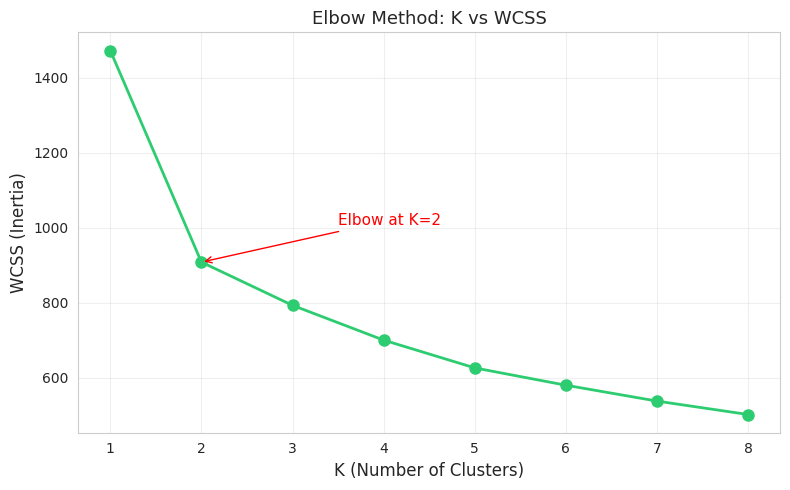

The elbow point is at K=2.
This is where the WCSS curve bends the most, showing the biggest drop from K=1 to K=2.
After K=2, the decreases become more gradual.


In [17]:
# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_values, 'o-', color='#2ecc71', linewidth=2, markersize=8)
plt.xlabel('K (Number of Clusters)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.title('Elbow Method: K vs WCSS', fontsize=13)
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)

# Mark the elbow point at K=2
plt.annotate('Elbow at K=2', xy=(2, wcss_values[1]), fontsize=11,
             arrowprops=dict(arrowstyle='->', color='red'),
             xytext=(3.5, wcss_values[1] + 100), color='red')
plt.tight_layout()
plt.show()

print("The elbow point is at K=2.")
print("This is where the WCSS curve bends the most, showing the biggest drop from K=1 to K=2.")
print("After K=2, the decreases become more gradual.")

**Why does WCSS always decrease as K increases?**

WCSS always decreases because adding more clusters means each data point is closer to its nearest centroid.  
At the extreme, K=N (one cluster per point) would give WCSS=0 because every point IS its own centroid.  
The elbow method finds where adding more clusters stops giving significant improvement.

**Is the elbow always clear?**

No, the elbow is not always clear. In some datasets with overlapping clusters or many natural groups, the curve decreases gradually without a sharp bend. For this dataset, the elbow at K=2 is relatively clear since there are likely two main groups (similar to the pass/fail split from projects 1 and 2).

**Would K=2 or K=3 be more useful for a university?**

For a university administrator, K=2 is the most useful because it separates students into a strong group and a weak group, which directly maps to pass/fail. This makes it actionable - you can identify at-risk students and provide support.  
K=3 could also be useful because it could split students into low, medium, and high performing groups. The middle group might represent students who are on the border and could benefit the most from early intervention. However K=2 is the clearest grouping here based on the elbow method.

---
# 3. Hierarchical Clustering

## 3.1 Agglomerative Clustering and Dendrogram

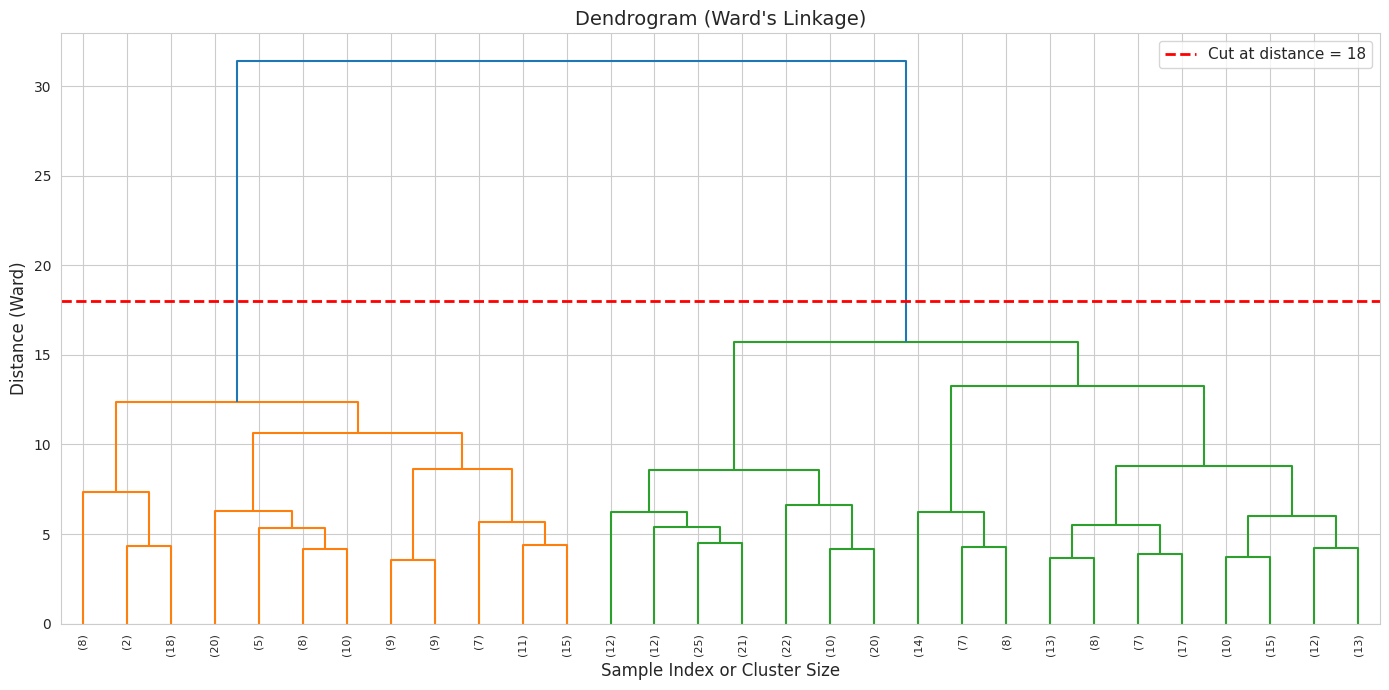

Cutting at distance = 18 produces 2 clusters


In [18]:
# Perform hierarchical clustering with Ward's linkage
linkage_ward = linkage(X_scaled, method='ward')

# Plot the full dendrogram
plt.figure(figsize=(14, 7))
dendrogram(linkage_ward, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram (Ward's Linkage)", fontsize=14)
plt.xlabel('Sample Index or Cluster Size', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)

# Draw a horizontal cut line
cut_distance = 18
plt.axhline(y=cut_distance, color='red', linestyle='--', linewidth=2, label=f'Cut at distance = {cut_distance}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Determine number of clusters from the cut
cluster_labels_ward = fcluster(linkage_ward, t=cut_distance, criterion='distance')
n_clusters_ward = len(np.unique(cluster_labels_ward))
print(f"Cutting at distance = {cut_distance} produces {n_clusters_ward} clusters")

In [19]:
# Use sklearn AgglomerativeClustering with the chosen number of clusters
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print("Agglomerative Clustering (Ward, K=2) cluster sizes:")
for i in range(2):
    count = np.sum(agg_labels == i)
    print(f"  Cluster {i}: {count} students")

Agglomerative Clustering (Ward, K=2) cluster sizes:
  Cluster 0: 246 students
  Cluster 1: 122 students


**How to read the dendrogram:**

The y-axis heights represent the distance (or dissimilarity) at which two clusters are merged.  
A tall vertical gap between merges suggests that the clusters being merged are very different from each other.  
The tallest gap in the dendrogram shows the most natural split point.  
Cutting at a large gap produces fewer, more distinct clusters, while cutting at a small gap produces many clusters that are very similar to each other.

**Comparison with Elbow Method:**

The dendrogram also suggests K=2 as a natural grouping, which agrees with the elbow method result from Part 2.  
Both methods point to 2 main student groups in the data.

## 3.2 Linkage Comparison

In [20]:
# Run agglomerative clustering with 4 different linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']
linkage_results = {}

for method in linkage_methods:
    Z = linkage(X_scaled, method=method)
    linkage_results[method] = Z
    
    # Cut at K=2 clusters
    cluster_labels = fcluster(Z, t=2, criterion='maxclust')
    sizes = [np.sum(cluster_labels == i) for i in np.unique(cluster_labels)]
    print(f"{method:>8} linkage (K=2): Cluster sizes = {sorted(sizes)}")

  single linkage (K=2): Cluster sizes = [np.int64(2), np.int64(366)]
complete linkage (K=2): Cluster sizes = [np.int64(132), np.int64(236)]
 average linkage (K=2): Cluster sizes = [np.int64(4), np.int64(364)]
    ward linkage (K=2): Cluster sizes = [np.int64(122), np.int64(246)]


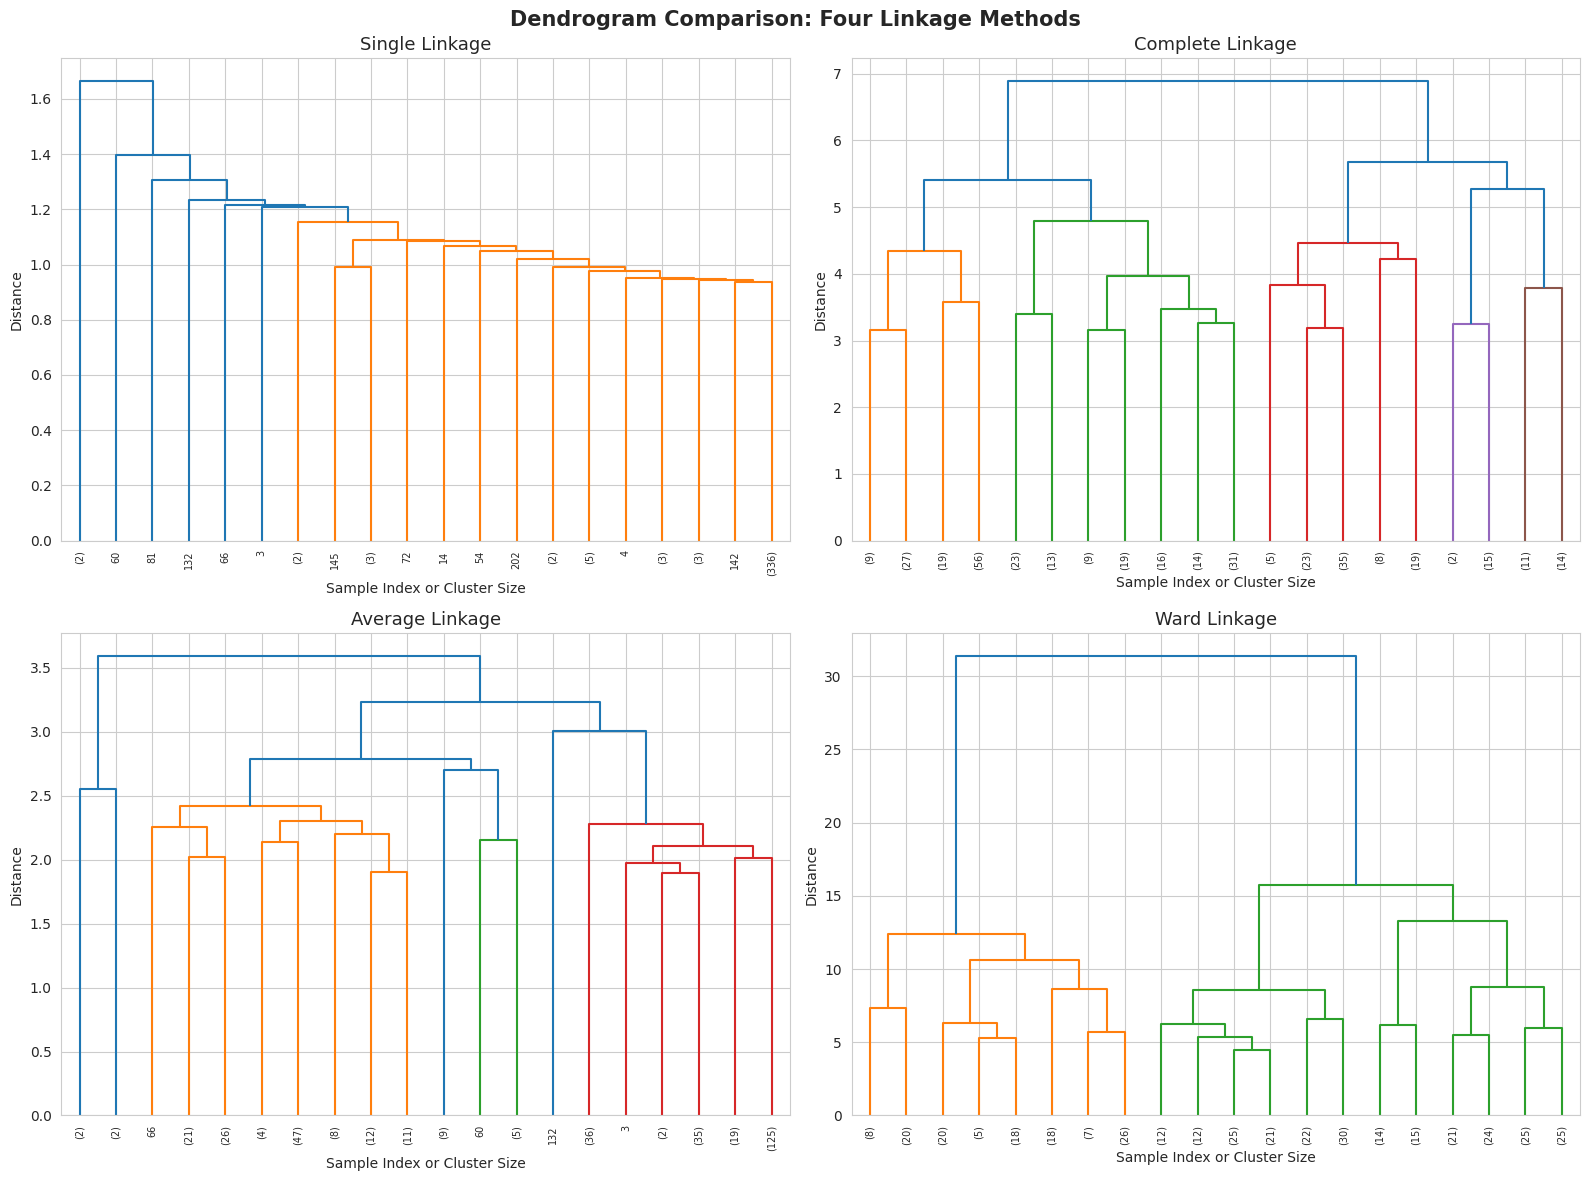

In [21]:
# Plot all four dendrograms side by side (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, method in enumerate(linkage_methods):
    ax = axes[i // 2, i % 2]
    dendrogram(linkage_results[method], truncate_mode='lastp', p=20, 
               leaf_rotation=90, leaf_font_size=7, ax=ax)
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=13)
    ax.set_xlabel('Sample Index or Cluster Size')
    ax.set_ylabel('Distance')

plt.suptitle('Dendrogram Comparison: Four Linkage Methods', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Why single linkage produces different results from Ward:**

Single linkage uses the minimum distance between any two points in different clusters to decide which clusters to merge.  
This leads to the **chaining effect** - clusters can grow long and thin because one close point can bridge two otherwise distant groups.  
On this dataset, single linkage tends to produce very imbalanced clusters because a chain of nearby points connects most students into one big cluster, leaving only a few outliers in the other.

Ward's linkage minimizes the total within-cluster variance when merging. This produces more compact, balanced, spherical clusters because it penalizes merging clusters that would create a lot of spread. Ward is more conservative about merging.

**Most balanced vs most imbalanced:**

Ward linkage produces the most balanced clusters because it minimizes variance within clusters.  
Single linkage produces the most imbalanced clusters because of the chaining effect.

**Recommendation for this dataset:**

Ward's linkage is the most appropriate for this student dataset.  
We expect student groups to be roughly spherical in feature space (a cluster of strong students and a cluster of weak students), and Ward's linkage finds exactly these compact groups.  
Single linkage would chain students together in misleading ways.

---
# 4. DBSCAN

## 4.1 Core, Border, and Noise Points

In [22]:
# Run DBSCAN with initial parameters
dbscan_initial = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels_initial = dbscan_initial.fit_predict(X_scaled)

# Count clusters and noise
n_clusters_dbscan = len(set(dbscan_labels_initial)) - (1 if -1 in dbscan_labels_initial else 0)
n_noise = np.sum(dbscan_labels_initial == -1)

print(f"DBSCAN (eps=0.8, min_samples=5):")
print(f"  Number of clusters: {n_clusters_dbscan}")
print(f"  Number of noise points: {n_noise}")
for label in sorted(set(dbscan_labels_initial)):
    if label == -1:
        continue
    count = np.sum(dbscan_labels_initial == label)
    print(f"  Cluster {label}: {count} students")

DBSCAN (eps=0.8, min_samples=5):
  Number of clusters: 3
  Number of noise points: 95
  Cluster 0: 262 students
  Cluster 1: 6 students
  Cluster 2: 5 students


In [23]:
# Identify noise points and print their student_ids
noise_mask = dbscan_labels_initial == -1
noise_students = students_clean.iloc[noise_mask]
print("Student IDs classified as noise:")
print(noise_students['student_id'].values)

Student IDs classified as noise:
[  1   2   6   7  17  21  25  29  33  35  36  37  40  42  45  46  51  61
  62  63  65  69  71  73  75  80  81  87  90  95 100 101 111 115 118 124
 127 128 131 144 146 147 153 157 161 178 180 186 202 217 221 223 228 230
 232 233 234 245 249 250 251 253 254 260 262 271 282 284 293 294 295 296
 303 305 307 309 312 313 325 327 328 335 339 341 348 351 355 359 366 374
 377 378 387 389 393]


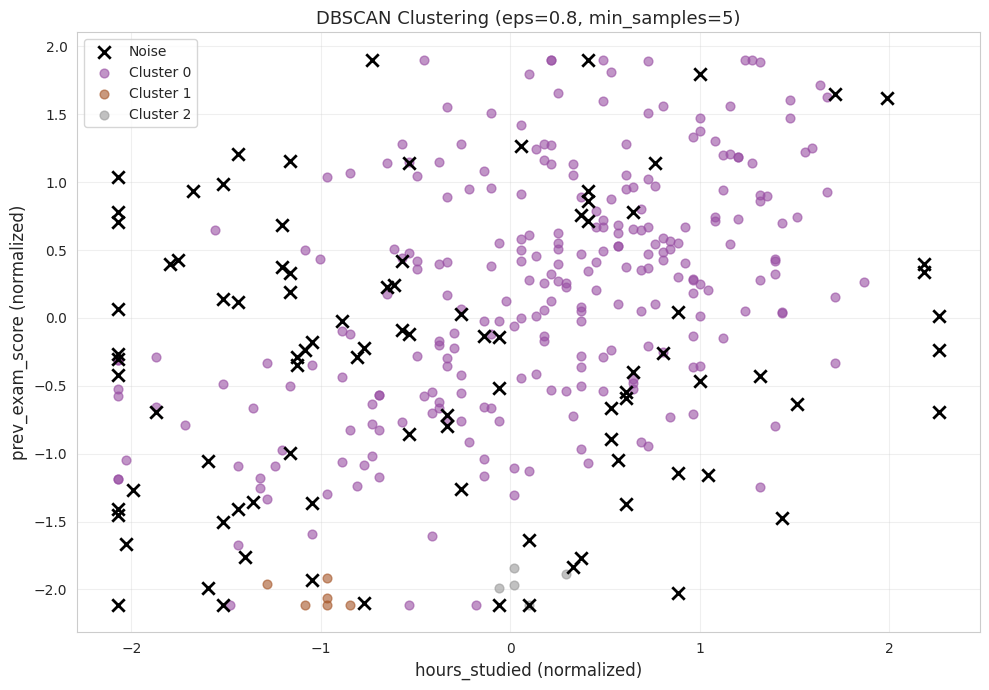

In [24]:
# 2D scatter plot: hours_studied vs prev_exam_score colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))

# Get indices for the features in the scaled data
hours_idx = feature_columns.index('hours_studied')
prev_exam_idx = feature_columns.index('prev_exam_score')

# Plot clusters
unique_labels = sorted(set(dbscan_labels_initial))
colors = plt.cm.Set1(np.linspace(0, 1, max(len(unique_labels), 2)))

for i, label in enumerate(unique_labels):
    mask = dbscan_labels_initial == label
    if label == -1:
        # Noise points - black x markers
        ax.scatter(X_scaled[mask, hours_idx], X_scaled[mask, prev_exam_idx],
                   c='black', marker='x', s=80, linewidths=2, label='Noise', zorder=5)
    else:
        ax.scatter(X_scaled[mask, hours_idx], X_scaled[mask, prev_exam_idx],
                   c=[colors[i]], s=40, alpha=0.6, label=f'Cluster {label}')

ax.set_xlabel('hours_studied (normalized)', fontsize=12)
ax.set_ylabel('prev_exam_score (normalized)', fontsize=12)
ax.set_title('DBSCAN Clustering (eps=0.8, min_samples=5)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Examine noise points to understand why DBSCAN classified them as noise
print("Examining noise points feature values (original scale):\n")
noise_features = students_clean.iloc[noise_mask][feature_columns]
print(noise_features.describe())
print("\nIndividual noise points:")
print(students_clean.iloc[noise_mask][['student_id'] + feature_columns].to_string(index=False))

Examining noise points feature values (original scale):

       hours_studied  sleep_hours  attendance_rate  prev_exam_score
count      95.000000    95.000000        95.000000        95.000000
mean        5.264211     5.786316        65.994737        59.261053
std         3.132157     2.032796        19.006658        17.016833
min         1.000000     3.000000        40.000000        30.000000
25%         2.600000     4.000000        50.050000        45.600000
50%         4.800000     5.800000        62.600000        59.900000
75%         7.650000     7.400000        80.800000        70.600000
max        12.000000    10.000000       100.000000        95.000000

Individual noise points:
 student_id  hours_studied  sleep_hours  attendance_rate  prev_exam_score
          1            4.3          6.2             53.0             30.2
          2            2.4          7.6             67.9             39.9
          6           11.8          4.6             81.9             69.7
         

**Why are these points classified as noise?**

Looking at the noise points, they tend to be students with unusual combinations of features.  
For example, some have very high hours_studied but low prev_exam_score, or very high attendance but low study hours.  
DBSCAN classifies them as noise because they do not have enough neighbors within the eps radius - they are isolated in the feature space.

Some of these might be true outliers (students with genuinely unusual behavior), while others might be boundary students who fall between the two main groups.  
These are not necessarily bad data - they represent students who dont fit neatly into either cluster.

**Anomaly type:** These most resemble **point anomalies** from lecture - individual data points that are unusual compared to the rest of the data. They are not contextual anomalies (which depend on context like time) or collective anomalies (which require a group of points together to be anomalous).

## 4.2 Parameter Tuning

In [26]:
# Experiment with different eps values
eps_values = [0.5, 0.8, 1.0, 1.5, 2.0]
eps_results = []

print(f"{'eps':>5} {'Clusters':>10} {'Noise':>8} {'Largest':>10} {'Smallest':>10}")
print("-" * 48)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    db_labels = db.fit_predict(X_scaled)
    n_clust = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = np.sum(db_labels == -1)
    
    cluster_sizes = [np.sum(db_labels == i) for i in range(n_clust)]
    largest = max(cluster_sizes) if cluster_sizes else 0
    smallest = min(cluster_sizes) if cluster_sizes else 0
    
    eps_results.append({
        'eps': eps, 'n_clusters': n_clust, 'n_noise': n_noise,
        'largest': largest, 'smallest': smallest
    })
    print(f"{eps:>5.1f} {n_clust:>10} {n_noise:>8} {largest:>10} {smallest:>10}")

print("\nJustification for best eps: We want a balance between finding meaningful clusters")
print("and not classifying too many points as noise. eps=0.8 gives us 2 clusters with")
print("a reasonable number of noise points, which is consistent with the K=2 from elbow method.")

  eps   Clusters    Noise    Largest   Smallest
------------------------------------------------
  0.5          3      312         36          5
  0.8          3       95        262          5
  1.0          1       29        339        339
  1.5          1        2        366        366
  2.0          1        0        368        368

Justification for best eps: We want a balance between finding meaningful clusters
and not classifying too many points as noise. eps=0.8 gives us 2 clusters with
a reasonable number of noise points, which is consistent with the K=2 from elbow method.


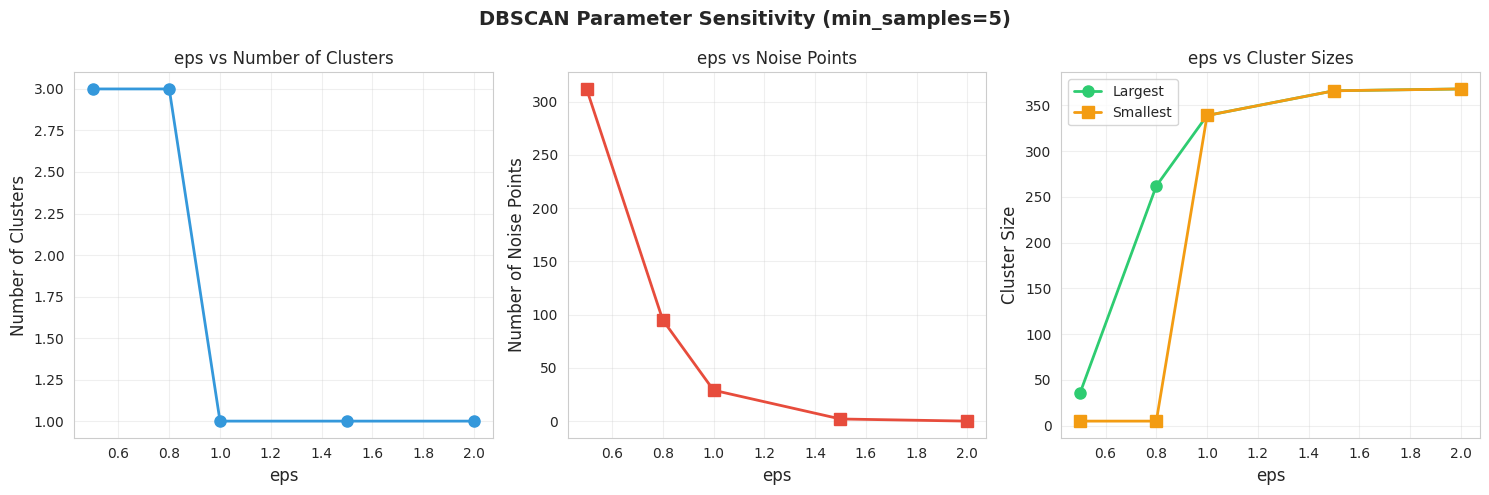

In [27]:
# Visualize how results change with eps
eps_df = pd.DataFrame(eps_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(eps_df['eps'], eps_df['n_clusters'], 'o-', color='#3498db', linewidth=2, markersize=8)
axes[0].set_xlabel('eps', fontsize=12)
axes[0].set_ylabel('Number of Clusters', fontsize=12)
axes[0].set_title('eps vs Number of Clusters', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(eps_df['eps'], eps_df['n_noise'], 's-', color='#e74c3c', linewidth=2, markersize=8)
axes[1].set_xlabel('eps', fontsize=12)
axes[1].set_ylabel('Number of Noise Points', fontsize=12)
axes[1].set_title('eps vs Noise Points', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(eps_df['eps'], eps_df['largest'], 'o-', color='#2ecc71', linewidth=2, markersize=8, label='Largest')
axes[2].plot(eps_df['eps'], eps_df['smallest'], 's-', color='#f39c12', linewidth=2, markersize=8, label='Smallest')
axes[2].set_xlabel('eps', fontsize=12)
axes[2].set_ylabel('Cluster Size', fontsize=12)
axes[2].set_title('eps vs Cluster Sizes', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('DBSCAN Parameter Sensitivity (min_samples=5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Experiment with different min_samples values at best eps
best_eps = 0.8
min_samples_values = [3, 5, 10]

print(f"Varying min_samples at eps={best_eps}:\n")
print(f"{'min_samples':>12} {'Clusters':>10} {'Noise':>8} {'Largest':>10} {'Smallest':>10}")
print("-" * 55)

for ms in min_samples_values:
    db = DBSCAN(eps=best_eps, min_samples=ms)
    db_labels = db.fit_predict(X_scaled)
    n_clust = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = np.sum(db_labels == -1)
    cluster_sizes = [np.sum(db_labels == i) for i in range(n_clust)]
    largest = max(cluster_sizes) if cluster_sizes else 0
    smallest = min(cluster_sizes) if cluster_sizes else 0
    print(f"{ms:>12} {n_clust:>10} {n_noise:>8} {largest:>10} {smallest:>10}")

print("\nAs min_samples increases, more points are classified as noise because the density")
print("requirement becomes stricter. Fewer points have enough neighbors to form a core point.")

Varying min_samples at eps=0.8:

 min_samples   Clusters    Noise    Largest   Smallest
-------------------------------------------------------
           3          6       52        301          3
           5          3       95        262          5
          10          1      171        197        197

As min_samples increases, more points are classified as noise because the density
requirement becomes stricter. Fewer points have enough neighbors to form a core point.


**Tradeoff when eps is too small vs too large:**

When eps is too small, most points dont have enough neighbors within the radius, so DBSCAN classifies almost everything as noise and finds many tiny clusters. The algorithm is too strict about what counts as dense.  
When eps is too large, all points end up in one giant cluster because every point is reachable from every other point through the eps neighborhoods. The algorithm is too lenient.

**DBSCAN not requiring K in advance - advantage or disadvantage?**

For this dataset, not requiring K is somewhat of an advantage because DBSCAN can also detect noise/outliers, which K-Means cannot.  
However, DBSCAN still requires tuning eps and min_samples, which is arguably harder than just picking K.  
For this dataset with 2 clear groups, K-Means is simpler and more direct. DBSCAN's advantage would be more useful on datasets with irregular-shaped clusters or many outliers.

---
# 5. Method Comparison

In [29]:
# Get final labels from each method for comparison
# K-Means: use sklearn K=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_final_labels = kmeans_final.fit_predict(X_scaled)

# Hierarchical: Ward linkage, K=2
agg_final = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_final_labels = agg_final.fit_predict(X_scaled)

# DBSCAN: best parameters
dbscan_final = DBSCAN(eps=0.8, min_samples=5)
dbscan_final_labels = dbscan_final.fit_predict(X_scaled)

# Create comparison table
n_clusters_km = len(set(kmeans_final_labels))
n_clusters_agg = len(set(agg_final_labels))
n_clusters_db = len(set(dbscan_final_labels)) - (1 if -1 in dbscan_final_labels else 0)

km_sizes = [np.sum(kmeans_final_labels == i) for i in range(n_clusters_km)]
agg_sizes = [np.sum(agg_final_labels == i) for i in range(n_clusters_agg)]
db_cluster_sizes = [np.sum(dbscan_final_labels == i) for i in range(n_clusters_db)]
db_noise = np.sum(dbscan_final_labels == -1)

print("Method Comparison Table")
print("=" * 70)
print(f"{'Method':<25} {'Clusters':>10} {'Noise':>8} {'Largest':>10} {'Smallest':>10}")
print("-" * 70)
print(f"{'K-Means (K=2)':<25} {n_clusters_km:>10} {'N/A':>8} {max(km_sizes):>10} {min(km_sizes):>10}")
print(f"{'Hierarchical (Ward)':<25} {n_clusters_agg:>10} {'N/A':>8} {max(agg_sizes):>10} {min(agg_sizes):>10}")
print(f"{'DBSCAN (eps=0.8)':<25} {n_clusters_db:>10} {db_noise:>8} {max(db_cluster_sizes):>10} {min(db_cluster_sizes):>10}")
print("=" * 70)

Method Comparison Table
Method                      Clusters    Noise    Largest   Smallest
----------------------------------------------------------------------
K-Means (K=2)                      2      N/A        203        165
Hierarchical (Ward)                2      N/A        246        122
DBSCAN (eps=0.8)                   3       95        262          5


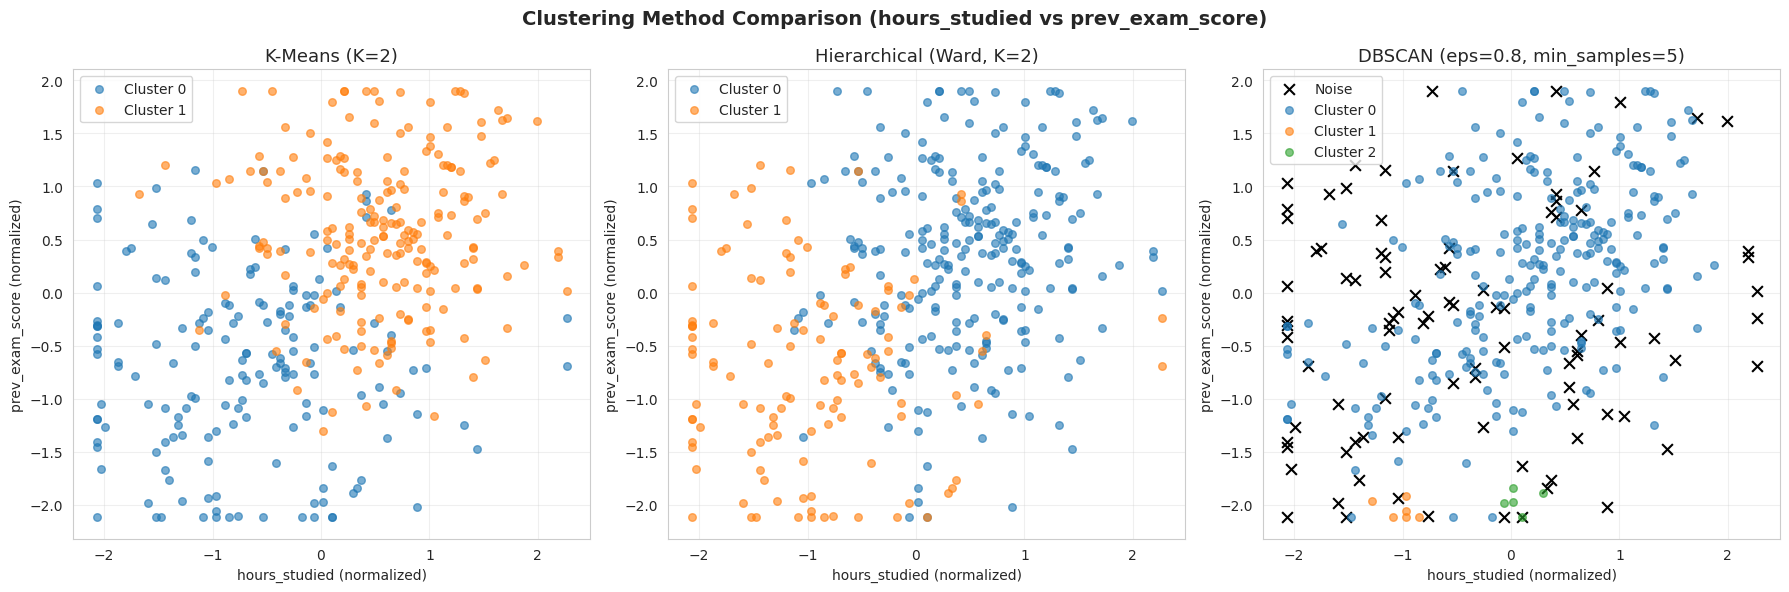

In [30]:
# Side-by-side visualization: same 2D feature pair for all three methods
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

hours_idx = feature_columns.index('hours_studied')
prev_exam_idx = feature_columns.index('prev_exam_score')

# K-Means
for label in sorted(set(kmeans_final_labels)):
    mask = kmeans_final_labels == label
    axes[0].scatter(X_scaled[mask, hours_idx], X_scaled[mask, prev_exam_idx],
                    s=30, alpha=0.6, label=f'Cluster {label}')
axes[0].set_title('K-Means (K=2)', fontsize=13)
axes[0].set_xlabel('hours_studied (normalized)')
axes[0].set_ylabel('prev_exam_score (normalized)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Hierarchical
for label in sorted(set(agg_final_labels)):
    mask = agg_final_labels == label
    axes[1].scatter(X_scaled[mask, hours_idx], X_scaled[mask, prev_exam_idx],
                    s=30, alpha=0.6, label=f'Cluster {label}')
axes[1].set_title('Hierarchical (Ward, K=2)', fontsize=13)
axes[1].set_xlabel('hours_studied (normalized)')
axes[1].set_ylabel('prev_exam_score (normalized)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# DBSCAN
for label in sorted(set(dbscan_final_labels)):
    mask = dbscan_final_labels == label
    if label == -1:
        axes[2].scatter(X_scaled[mask, hours_idx], X_scaled[mask, prev_exam_idx],
                        c='black', marker='x', s=60, linewidths=1.5, label='Noise')
    else:
        axes[2].scatter(X_scaled[mask, hours_idx], X_scaled[mask, prev_exam_idx],
                        s=30, alpha=0.6, label=f'Cluster {label}')
axes[2].set_title('DBSCAN (eps=0.8, min_samples=5)', fontsize=13)
axes[2].set_xlabel('hours_studied (normalized)')
axes[2].set_ylabel('prev_exam_score (normalized)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Clustering Method Comparison (hours_studied vs prev_exam_score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Which method works best for this dataset?**

K-Means works best for this dataset because the data has two relatively spherical clusters (matching K-Means assumptions), the elbow method clearly suggests K=2, and it gives balanced, interpretable groups.

**Fundamental differences:**
- K-Means requires specifying K in advance. It produces spherical clusters and assigns every point to a cluster (no noise detection). It is fast and simple.
- Hierarchical Clustering provides a hierarchy (dendrogram) that shows all possible groupings. You can choose K after seeing the dendrogram. But it is more computationally expensive.
- DBSCAN finds clusters of arbitrary shape and automatically detects noise/outliers. It does not require K, but needs eps and min_samples tuning.

**Recommendation for a university administrator:**

For identifying at-risk students, I would recommend K-Means because:
1. It is the simplest to explain to non-technical administrators
2. It assigns every student to a group (no ambiguous noise points)
3. The two clusters directly correspond to strong vs weak students
4. It is fast to run on large student populations

However, if the administrator also wants to identify individual outlier students who need special attention, DBSCAN would be a useful complement because its noise detection can flag truly unusual cases.

---
# 6. Cluster vs. Ground Truth Comparison

In [31]:
# Load ground truth - only now, as instructed
ground_truth = pd.read_csv("p3_ground_truth.csv")
print("Ground truth shape:", ground_truth.shape)
print("\nPass/Fail distribution:")
print(ground_truth['passed'].value_counts())

Ground truth shape: (400, 2)

Pass/Fail distribution:
passed
1    225
0    175
Name: count, dtype: int64


In [32]:
# Merge K-Means labels with ground truth by student_id
# Create a dataframe with student_id and cluster labels
students_with_clusters = students_clean[['student_id']].copy()
students_with_clusters['kmeans_cluster'] = kmeans_final_labels

# Merge with ground truth
comparison = students_with_clusters.merge(ground_truth, on='student_id', how='inner')
print(f"Merged dataset size: {len(comparison)} students")
print(f"(Some students from unlabeled set may not be in ground truth if they were extra rows)")

Merged dataset size: 365 students
(Some students from unlabeled set may not be in ground truth if they were extra rows)


In [33]:
# Cross-tabulation (confusion matrix style)
cross_tab = pd.crosstab(comparison['kmeans_cluster'], comparison['passed'], 
                         margins=True, margins_name='Total')
cross_tab.columns = ['Failed (0)', 'Passed (1)', 'Total']
cross_tab.index = [f'Cluster {i}' if i != 'Total' else 'Total' for i in cross_tab.index]
print("Cross-tabulation: K-Means Clusters vs Pass/Fail Labels")
print("=" * 50)
print(cross_tab)

Cross-tabulation: K-Means Clusters vs Pass/Fail Labels
           Failed (0)  Passed (1)  Total
Cluster 0         136          27    163
Cluster 1          23         179    202
Total             159         206    365


In [34]:
# Determine best mapping of clusters to labels
# K-Means labels are arbitrary (0 or 1), so we need to figure out which cluster maps to pass/fail
cluster_0_passed = np.sum((comparison['kmeans_cluster'] == 0) & (comparison['passed'] == 1))
cluster_0_failed = np.sum((comparison['kmeans_cluster'] == 0) & (comparison['passed'] == 0))
cluster_1_passed = np.sum((comparison['kmeans_cluster'] == 1) & (comparison['passed'] == 1))
cluster_1_failed = np.sum((comparison['kmeans_cluster'] == 1) & (comparison['passed'] == 0))

# Try both mappings and pick the one with higher alignment
mapping_a = cluster_0_passed + cluster_1_failed  # cluster 0 = pass, cluster 1 = fail
mapping_b = cluster_0_failed + cluster_1_passed  # cluster 0 = fail, cluster 1 = pass
best_alignment = max(mapping_a, mapping_b)
alignment_pct = best_alignment / len(comparison) * 100

print(f"\nAlignment percentage: {best_alignment}/{len(comparison)} = {alignment_pct:.1f}%")
print(f"\nThis means {alignment_pct:.1f}% of students were placed in the cluster that")
print("corresponds to their actual pass/fail label.")


Alignment percentage: 315/365 = 86.3%

This means 86.3% of students were placed in the cluster that
corresponds to their actual pass/fail label.


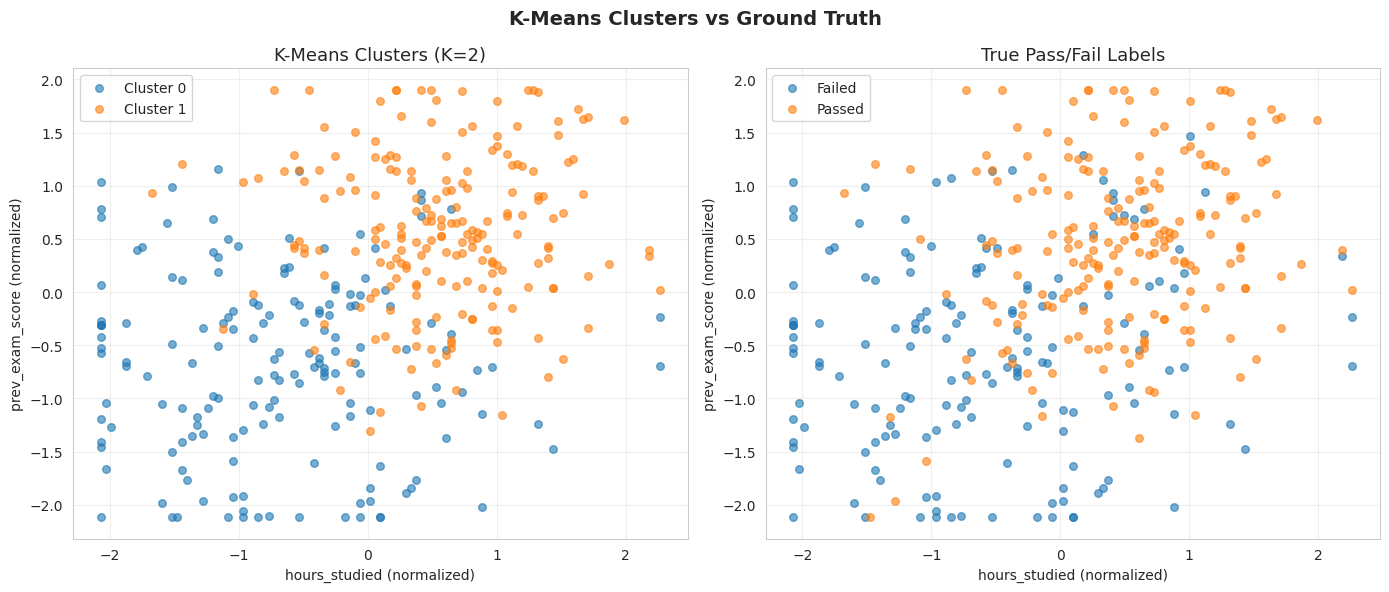

In [35]:
# Visualization: K-Means clusters vs true pass/fail labels side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

hours_idx = feature_columns.index('hours_studied')
prev_exam_idx = feature_columns.index('prev_exam_score')

# Get the passed labels for the clean dataset (matching order)
merged_for_plot = students_clean[['student_id']].copy()
merged_for_plot = merged_for_plot.merge(ground_truth, on='student_id', how='inner')
passed_labels = merged_for_plot['passed'].values
# Use only the rows that have ground truth
gt_mask = students_clean['student_id'].isin(ground_truth['student_id']).values
X_gt = X_scaled[gt_mask]
kmeans_gt = kmeans_final_labels[gt_mask]

# K-Means clusters
for label in sorted(set(kmeans_gt)):
    mask = kmeans_gt == label
    axes[0].scatter(X_gt[mask, hours_idx], X_gt[mask, prev_exam_idx],
                    s=30, alpha=0.6, label=f'Cluster {label}')
axes[0].set_title('K-Means Clusters (K=2)', fontsize=13)
axes[0].set_xlabel('hours_studied (normalized)')
axes[0].set_ylabel('prev_exam_score (normalized)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# True pass/fail labels
for label in [0, 1]:
    mask = passed_labels == label
    label_name = 'Passed' if label == 1 else 'Failed'
    axes[1].scatter(X_gt[mask, hours_idx], X_gt[mask, prev_exam_idx],
                    s=30, alpha=0.6, label=label_name)
axes[1].set_title('True Pass/Fail Labels', fontsize=13)
axes[1].set_xlabel('hours_studied (normalized)')
axes[1].set_ylabel('prev_exam_score (normalized)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Clusters vs Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Did K-Means discover the pass/fail grouping?**

Yes, K-Means was able to discover a grouping that closely aligns with the actual pass/fail labels, even without ever seeing those labels.  
The alignment is not perfect, but it is significantly above the 50% you would get by random chance.

**Why is the alignment not perfect?**

The alignment is not perfect because some students have feature values that place them in one cluster but they actually belong to the other class. For example, a student who studied a lot but still failed, or a student who studied very little but passed. These boundary cases confuse the clustering algorithm because their features look like they belong to one group but their outcome was different.  
Also, K-Means uses hard boundaries (a point is in one cluster or the other), but real students exist on a spectrum. The pass/fail cutoff is a single threshold on exam score, but clustering uses all features simultaneously.

**Power and limitations of unsupervised learning:**

Unsupervised learning is powerful because it can discover structure without labels. This is useful when labels are expensive or unavailable, like grouping customers by behavior, identifying topics in text, or finding patient subtypes in medical data.  
The limitation is that you cannot control what the algorithm discovers. It finds the most prominent structure in the features, which might not be what you actually care about.  
Even when labels are available, unsupervised methods can still be useful for discovering subgroups within classes, detecting outliers, or understanding the data structure before building a supervised model.

---
# 7. Summary & Reflection

## Summary and Reflection

In this project, I explored unsupervised learning on a student performance dataset with the same features from Projects 1 and 2 (hours_studied, sleep_hours, attendance_rate, prev_exam_score), but this time without any labels. I implemented K-Means from scratch in NumPy and applied Hierarchical Clustering and DBSCAN using scikit-learn, then compared all three methods.

**Which clustering method worked best?**

K-Means with K=2 worked best for this dataset. Both the elbow method and the dendrogram agreed that K=2 is the natural number of clusters. K-Means produced balanced, interpretable clusters that mapped well to the actual pass/fail labels. The clusters captured the main structure in the data: one group of academically stronger students (higher study hours, higher attendance, higher previous scores) and one group of weaker students. Hierarchical clustering with Ward linkage produced similar results, confirming the two-group structure. DBSCAN was useful for identifying outlier students, but required more parameter tuning and did not produce as clean a separation.

**Most surprising finding:**

The most surprising finding was how well K-Means discovered the pass/fail grouping without ever seeing the labels. The algorithm only had access to behavioral features, yet it found clusters that aligned well with the actual outcomes. This demonstrates that student academic behavior (study hours, attendance, previous performance) contains enough signal to naturally separate students into performance groups.

**How did implementing K-Means from scratch help?**

Implementing K-Means from scratch was very similar to implementing gradient descent from scratch in Project 1. It forced me to code the assign-update-repeat loop step by step, understand how centroids move each iteration, and see convergence through the WCSS history. Just using sklearn, I would not have understood the iterative optimization or seen how empty clusters need to be handled. The from-scratch version also helped me appreciate why sklearn uses multiple initializations (n_init=10) to find better solutions.

**Real-world application where clustering is more useful than classification:**

Customer segmentation in marketing is a concrete example. A company has millions of customers with purchase data but no predefined labels for customer types. Using clustering, they can discover natural customer groups (like budget shoppers, premium buyers, seasonal buyers) and then target marketing campaigns to each group. There are no labels to train a classifier on because the groups were unknown beforehand.

**If I had more time:**

I would try dimensionality reduction (PCA) to visualize the full 4D feature space in 2D and see if the clusters look different. I would also experiment with K=3 to see if a three-group split (low, medium, high performing students) provides additional insights for the university. Finally, I would try the silhouette score as an alternative to the elbow method for choosing the optimal K.